In [38]:
from MieSppForce.simulation import SimulationConfig, SweepRunner,  DipoleCalculator, OpticalForceCalculator, DiagramCalculator, CylindricalGrid, SphericalGrid, DiagramResult
import matplotlib.pyplot as plt
import numpy as np
from pint import UnitRegistry
ureg = UnitRegistry()

base_config = SimulationConfig(
    wl = 900 * ureg.nanometer,
    R =  100 * ureg.nanometer,
    dist = 2 * ureg.nanometer,
    angle = np.deg2rad(25),
    psi = 0,
    chi = np.pi/4,
    show_warnings=False,
    initial_field_type='plane_wave'
)

num_points = 100

XOY= SphericalGrid(
    r= base_config.wl,
    theta = np.linspace(0, np.pi/2, 30) * ureg.rad,
    phi = np.linspace(0, 2*np.pi, 60) * ureg.rad
)

R_arr = np.linspace(100, 165, num_points)*ureg.nanometer


In [ ]:
from MieSppForce.simulation import ExtinctionCalculator

ExtinctionCalculator(base_config).compute()

In [ ]:
res, _,_ = SweepRunner(base_config, 'R', np.linspace(100, 165, num_points)*ureg.nanometer, True, True, False, False, False).run(n_jobs=-1)

In [ ]:
import matplotlib.pyplot as plt

plt.plot(res.R, res.sigma_spp, label='sigma_spp')
plt.plot(res.R, res.sigma_air, label='sigma_air')
plt.plot(res.R, res.sigma_tot, label='sigma_tot')
plt.xlabel('R (nm)')
plt.ylabel('Extinction cross-section (a.u.)')
plt.title('Extinction cross-section vs R')
plt.legend()
plt.grid()
plt.show()

In [ ]:
sweep_reg, diagrams_reg, _ = SweepRunner(base_config, 'R', R_arr , True, False ,True, True, False, XOY, 'reg', diagram_normalize=None).run(n_jobs=-1)
sweep_spp, diagrams_spp, _ = SweepRunner(base_config, 'R', R_arr, True, False, True, True, False, XOY, 'spp', diagram_normalize=None).run(n_jobs=-1)
sweep_tot, diagrams_tot, _ = SweepRunner(base_config, 'R', R_arr, True, False, True, True, False, XOY, '', diagram_normalize=None).run(n_jobs=-1)

  0%|          | 0/100 [00:00<?, ?it/s]

  0%|          | 0/100 [00:00<?, ?it/s]

  0%|          | 0/100 [00:00<?, ?it/s]

  0%|          | 0/100 [00:00<?, ?it/s]

  0%|          | 0/100 [06:16<?, ?it/s]


In [28]:
diagrams_reg.D[diagrams_reg.D<0] = 0 
diagrams_spp.D[diagrams_spp.D<0] = 0 
diagrams_tot.D[diagrams_tot.D<0] = 0 


/var/folders/rm/jp69z42j5kv7gm1yn340dwx80000gn/T/ipykernel_47380/1374821615.py:1: FutureWarning: ChainedAssignmentError: behaviour will change in pandas 3.0!
You are setting values through chained assignment. Currently this works in certain cases, but when using Copy-on-Write (which will become the default behaviour in pandas 3.0) this will never work to update the original DataFrame or Series, because the intermediate object on which we are setting values will behave as a copy.
A typical example is when you are setting values in a column of a DataFrame, like:

df["col"][row_indexer] = value

Use `df.loc[row_indexer, "col"] = values` instead, to perform the assignment in a single step and ensure this keeps updating the original `df`.

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

  diagrams_reg.D[diagrams_reg.D<0] = 0
/var/folders/rm/jp69z42j5kv7gm1yn340dwx80000gn/T/ipykernel_47380/1374821615.

In [29]:
import numpy as np
import pandas as pd

def integrate_pattern_over_theta(
    diagrams_df: pd.DataFrame,
    *,
    phi_col: str = "phi",
    theta_col: str = "theta",
    R_col: str = "R",
    D_col: str = "D",
) -> pd.DataFrame:
    """
    Интегрирует 3D диаграмму D(phi, theta) по theta:
        p(phi, R) = ∫_{theta_min}^{theta_max} D(phi, theta, R) * sin(theta) dtheta

    Возвращает DataFrame с колонками: [R, phi, p]
    """

    def _to_float(x):
        if hasattr(x, "magnitude"):
            return float(x.magnitude)
        return float(x)

    df = diagrams_df.copy()
    df[phi_col] = df[phi_col].apply(_to_float)
    df[theta_col] = df[theta_col].apply(_to_float)
    df[R_col] = df[R_col].apply(_to_float)
    df[D_col] = df[D_col].apply(_to_float)

    df = df.sort_values([R_col, phi_col, theta_col])

    def _integrate_group(g: pd.DataFrame) -> float:
        th = g[theta_col].to_numpy()
        D = g[D_col].to_numpy()
        y = D * np.sin(th)
        return float(np.trapezoid(y, th))

    out = (
        df.groupby([R_col, phi_col], as_index=False)
          .apply(lambda g: _integrate_group(g))
          .rename(columns={None: "p"})
          .reset_index(drop=True)
    )
    return out


def integrate_pattern_over_phi_after_theta(
    diagrams_df: pd.DataFrame,
    *,
    phi_col: str = "phi",
    R_col: str = "R",
    p_col: str = "p",
) -> pd.DataFrame:
    """
    Интегрирует 2D диаграмму p(phi) по phi:
    p(R) = ∫_{phi_min}^{phi_max} p(phi, theta, R) * sin(theta) dphi

    Возвращает DataFrame с колонками: [R, phi, p]
    """

    def _to_float(x):
        if hasattr(x, "magnitude"):
            return float(x.magnitude)
        return float(x)

    df = diagrams_df.copy()
    df[phi_col] = df[phi_col].apply(_to_float)
    df[R_col] = df[R_col].apply(_to_float)
    df[p_col] = df[p_col].apply(_to_float)

    df = df.sort_values([R_col, phi_col])

    def _integrate_group(g: pd.DataFrame) -> float:
        ph = g[phi_col].to_numpy()
        D = g[p_col].to_numpy()
        return float(np.trapezoid(D, ph))

    out = (
        df.groupby([R_col], as_index=False)
          .apply(lambda g: _integrate_group(g))
          .rename(columns={None: "p"})
          .reset_index(drop=True)
    )
    return out




In [30]:
int_spp_over_theta = integrate_pattern_over_theta(diagrams_spp)
int_spp_over_phi = integrate_pattern_over_phi_after_theta(int_spp_over_theta)

int_reg_over_theta = integrate_pattern_over_theta(diagrams_reg)
int_reg_over_phi = integrate_pattern_over_phi_after_theta(int_reg_over_theta)

int_tot_over_theta = integrate_pattern_over_theta(diagrams_tot)
int_tot_over_phi = integrate_pattern_over_phi_after_theta(int_tot_over_theta)

/var/folders/rm/jp69z42j5kv7gm1yn340dwx80000gn/T/ipykernel_47380/1863893119.py:40: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda g: _integrate_group(g))
/var/folders/rm/jp69z42j5kv7gm1yn340dwx80000gn/T/ipykernel_47380/1863893119.py:80: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda g: _integrate_group(g))
/var/folders/rm/jp69z42j5kv7gm1yn340dwx80000gn/T/ipykernel_47380/1863893119.py:40: Fut

In [39]:
I0 = base_config.c_const*base_config.eps0_const/2 


sigma_spp = int_spp_over_phi.p*XOY.r**2/(np.pi*R_arr**2)/I0.magnitude
sigma_air = int_reg_over_phi.p*XOY.r**2/(np.pi*R_arr**2)/I0.magnitude
sigma_tot = int_tot_over_phi.p*XOY.r**2/(np.pi*R_arr**2)/I0.magnitude

/Users/semyon_b/git/SPP_ANALYTICAL/.venv/lib/python3.13/site-packages/pandas/core/construction.py:627: UnitStrippedWarning: The unit of the quantity is stripped when downcasting to ndarray.
  data = np.asarray(data)


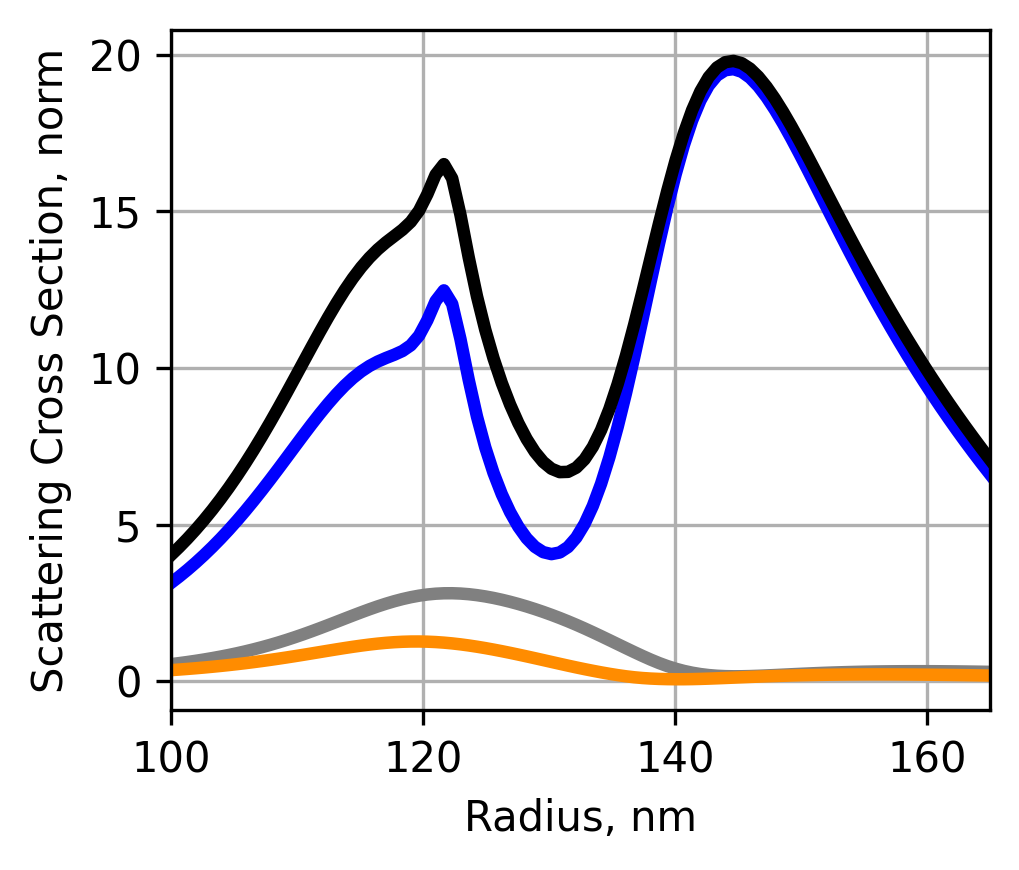

In [41]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.gridspec import GridSpec

import matplotlib.pyplot as plt
plt.rcParams['svg.fonttype'] = 'none'
plt.rcParams['text.usetex'] = False



fig = plt.figure(figsize=(3.5, 3), dpi=300)
ax = fig.add_subplot(1, 1, 1)


# ax.set_ylabel(r'$\sigma_{sc}$, norm')



plt.plot(int_reg_over_phi.R, sigma_air, label='Air', color='blue', lw=3)
plt.plot(int_tot_over_phi.R, sigma_tot, label='Total', color='black', lw=3)
plt.plot(int_tot_over_phi.R, sigma_tot-sigma_air-sigma_spp, label='Mix', color='gray', lw=3)
plt.plot(int_spp_over_phi.R, sigma_spp, label='SPP', color='darkorange', lw=3)

ax.set_ylabel('Scattering Cross Section, norm')
ax.set_xlabel('Radius, nm')
ax.grid()
# ax.legend(loc='upper right')
ax.set_xlim(100,165)
plt.tight_layout()
# plt.ylim(0,22)
plt.savefig('article_plots/figure 1/sc_cs_air_spp_mix_raw.svg', format="svg"
            # bbox_inches='tight', 
            # dpi=300
            )
plt.show()